# 02 — ML 모형 (Ridge / ElasticNet / Huber / LightGBM / XGBoost)

구간(평시·9·11·GFC·COVID) × 국가(US·KR·JP) × Feature tier(Core/Momentum/Extended) × 프로토콜(static·expanding) × phase 전체 그리드 평가.

**산출물**:
- `results/ml_results_core.csv` — Core tier만 (모든 모델·regime·country·protocol·phase)
- `results/ml_results_momentum.csv` — Momentum tier
- `results/ml_results_extended.csv` — Extended tier
- `results/ml_tuned_params.csv` — best 하이퍼파라미터 모음 (180행)
- `results/best_models/{model}/{regime}_{country}_{tier}.pkl` — 학습된 best 모델 객체 (joblib)

**모듈**:
- `src/preprocess/{features,scaler}.py` — feature 선택 + scaling
- `src/models/ml.py` — 5개 모델 wrapper
- `src/eval/tuning.py` — Optuna 튜닝 (QLIKE 최소화)
- `src/eval/protocols.py` — static / expanding

**확정 정책 (이번 대화에서 결정)**:
- Horizon: h=1만
- Refit_every: 5 (h=1 기준)
- Optuna trials: linear=15, tree=30
- Tuning metric: QLIKE
- Train/Valid/Test: CSV `split` 컬럼 그대로 (= `data_splits.txt` ML/DL 섹션)

## 0. 환경 설정

In [2]:
import os, sys
from pathlib import Path

# Colab인 경우 Drive 마운트
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    os.environ['FINTEL_PROJECT_ROOT'] = '/content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project'
except ImportError:
    pass

PROJECT_ROOT = Path(os.environ.get('FINTEL_PROJECT_ROOT', Path.cwd().parent))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project


In [3]:
!pip install -q -r /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.1 MB/s eta 0:00:00


In [4]:
import time, warnings, random
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings('ignore')

# ── Seed 고정 (재현성) ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from src import config
from src.data_loader import load_dataset
from src.preprocess import get_feature_list
from src.models import (
    ML_MODEL_REGISTRY, ALL_MODEL_NAMES,
    LINEAR_MODEL_NAMES, TREE_MODEL_NAMES,
    make_ml_model,
)
from src.eval import (
    evaluate, iter_phases,
    run_static, run_expanding,
    tune_model, default_n_trials,
)

print(f'Seed locked at {SEED}.')
print(f'  - np.random.seed({SEED})')
print(f'  - random.seed({SEED})')
print(f'  - 각 ML 모델 random_state={SEED} (src/models/ml.py)')
print(f'  - Optuna TPESampler(seed={SEED}) (src/eval/tuning.py)')

Seed locked at 42.
  - np.random.seed(42)
  - random.seed(42)
  - 각 ML 모델 random_state=42 (src/models/ml.py)
  - Optuna TPESampler(seed=42) (src/eval/tuning.py)


## 1. 그리드 정의

In [5]:
TIERS     = ['core', 'momentum', 'extended']
PROTOCOLS = ['static', 'expanding']
REFIT_EVERY = 5

# 개발 중엔 N_TRIALS_OVERRIDE를 작게(예: 3) 두면 빠르게 검증 가능. 최종 실행은 None.
N_TRIALS_OVERRIDE: int | None = None

print('regimes  :', config.REGIMES)
print('countries:', config.COUNTRIES)
print('tiers    :', TIERS)
print('models   :', list(ALL_MODEL_NAMES))
print('protocols:', PROTOCOLS)
print('metrics  :', config.METRICS)

regimes  : ['normal', '911', 'gfc', 'covid']
countries: ['US', 'KR', 'JP']
tiers    : ['core', 'momentum', 'extended']
models   : ['Ridge', 'ElasticNet', 'Huber', 'LightGBM', 'XGBoost']
protocols: ['static', 'expanding']
metrics  : ['RMSE', 'MAE', 'QLIKE', 'RMSE_CV']


## 2. CSV split으로 train/valid/test 로딩 헬퍼

In [6]:
def load_split_3way(regime: str, country: str):
    """CSV의 `split` 컬럼 기반 3분할. RV 관련 NaN 제거."""
    df = load_dataset(regime, country)
    df = df.dropna(subset=['RV_target','RV_d','RV_w','RV_m','log_return'])
    train = df[df['split']=='train'].copy()
    valid = df[df['split']=='valid'].copy()
    test  = df[df['split']=='test'].copy()
    return train, valid, test

# Sanity: normal/US 출력
tr, va, te = load_split_3way('normal','US')
print(f'normal/US  train={len(tr)}  valid={len(va)}  test={len(te)}')

normal/US  train=2982  valid=506  test=1502


## 3. 그리드 실행

각 (regime × country × tier × model) 조합:
1. Optuna 튜닝 (train + valid → best_params)
2. static + expanding 프로토콜로 test 예측
3. phase별 평가 → 결과 행 누적

**예상 소요 시간** (CPU 기준):
- 선형 3 × 12(regime×country) × 3 tier × n_trials=15 ≈ ~5분
- 트리 2 × 12 × 3 × n_trials=30 ≈ ~30분
- expanding은 각 모델당 추가 ~5~10분
- **총 1~2시간 예상**

In [7]:
results = []
preds_cache = {}        # (model, regime, country, tier, protocol) -> pd.Series
tuned_cache = {}        # (model, regime, country, tier) -> (best_params, best_qlike)

# Best fitted model 저장 디렉토리 준비
BEST_MODELS_DIR = config.RESULTS_DIR / 'best_models'
for model_name in ALL_MODEL_NAMES:
    (BEST_MODELS_DIR / model_name).mkdir(parents=True, exist_ok=True)

t_total = time.time()
for regime, country in product(config.REGIMES, config.COUNTRIES):
    train, valid, test = load_split_3way(regime, country)
    # ── 표준 ML pipeline ──
    # 튜닝: train(fit) + valid(eval) → best_params 결정
    # 학습: train + valid 합쳐서 final fit (static·expanding 모두) → test 평가
    combined = pd.concat([train, valid])
    print(f'\n[{regime}/{country}] train={len(train)} valid={len(valid)} '
          f'combined={len(combined)} test={len(test)}')

    for tier in TIERS:
        feats = get_feature_list(train, country, tier)
        for model_name in ALL_MODEL_NAMES:
            t_case = time.time()

            # 1) Optuna 튜닝 — train(fit), valid(eval)
            n_trials = N_TRIALS_OVERRIDE or default_n_trials(model_name)
            best_params, best_qlike = tune_model(
                model_name, train, valid, feats, n_trials=n_trials,
            )
            tuned_cache[(model_name, regime, country, tier)] = (best_params, best_qlike)

            # 2) 프로토콜별 예측 + best fitted model 저장
            #    static·expanding 모두 train+valid (combined)로 학습 시작
            for protocol in PROTOCOLS:
                if protocol == 'static':
                    final = make_ml_model(model_name, feats, **best_params).fit(combined)
                    y_pred = final.predict(test)

                    # ── best fitted model 저장 (model 별 폴더 분리) ──
                    pkl_path = BEST_MODELS_DIR / model_name / f'{regime}_{country}_{tier}.pkl'
                    joblib.dump({
                        'model': final,
                        'feature_cols': feats,
                        'best_params': best_params,
                        'best_val_qlike': best_qlike,
                        'regime': regime, 'country': country, 'tier': tier,
                        'fit_data': 'train+valid',  # combined 사용 명시
                    }, pkl_path)
                else:
                    ModelCls = ML_MODEL_REGISTRY[model_name]
                    # expanding: 초기 history = train+valid → test 흘려넣기
                    y_pred = run_expanding(
                        ModelCls, combined, test,
                        refit_every=REFIT_EVERY,
                        feature_cols=feats, **best_params,
                    )

                preds_cache[(model_name, regime, country, tier, protocol)] = y_pred

                # 3) phase별 평가
                for phase_name, mask, _color in iter_phases(test, regime):
                    if mask.sum() == 0:
                        continue
                    y_t = test.loc[mask, 'RV_target']
                    y_p = y_pred[mask]
                    metrics = evaluate(y_t, y_p)
                    results.append({
                        'model': model_name, 'regime': regime, 'country': country,
                        'feature_set': tier, 'protocol': protocol, 'phase': phase_name,
                        **metrics,
                        'best_val_qlike': best_qlike,
                        'n_features': len(feats),
                    })

            elapsed = time.time() - t_case
            print(f'  {tier:<10} {model_name:<10}  ({elapsed:.1f}s)  best_val_qlike={best_qlike:.4f}')

results_df = pd.DataFrame(results)
print(f'\n총 행: {len(results_df)} (예상 1080)  / 총 소요: {(time.time()-t_total)/60:.1f}분')
print(f'best fitted models 저장 위치: {BEST_MODELS_DIR}')


[normal/US] train=2982 valid=506 combined=3488 test=1502
  core       Ridge       (12.7s)  best_val_qlike=0.0308
  core       ElasticNet  (11.5s)  best_val_qlike=0.0297
  core       Huber       (91.7s)  best_val_qlike=0.0290
  core       LightGBM    (291.7s)  best_val_qlike=0.0262
  core       XGBoost     (171.0s)  best_val_qlike=0.0274
  momentum   Ridge       (14.2s)  best_val_qlike=0.0292
  momentum   ElasticNet  (14.6s)  best_val_qlike=0.0280
  momentum   Huber       (101.2s)  best_val_qlike=0.0279
  momentum   LightGBM    (170.4s)  best_val_qlike=0.0261
  momentum   XGBoost     (235.7s)  best_val_qlike=0.0270
  extended   Ridge       (32.9s)  best_val_qlike=0.0284
  extended   ElasticNet  (24.5s)  best_val_qlike=0.0277
  extended   Huber       (150.6s)  best_val_qlike=0.0272
  extended   LightGBM    (2942.8s)  best_val_qlike=0.0253
  extended   XGBoost     (458.7s)  best_val_qlike=0.0269

[normal/KR] train=2938 valid=488 combined=3426 test=1475
  core       Ridge       (11.8s)  b

## 4. 결과 저장 — tier별 분리 CSV

In [8]:
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# tier별 분리 저장 — 각 CSV는 모든 모델·regime·country·protocol·phase 행 포함
saved_files = []
for tier in TIERS:
    df_tier = results_df[results_df['feature_set'] == tier].copy()
    out = config.RESULTS_DIR / f'ml_results_{tier}.csv'
    df_tier.to_csv(out, index=False)
    saved_files.append((out, len(df_tier)))

for out, n in saved_files:
    print(f'  saved → {out.name}  ({n}행)')

print(f'\n총합: {sum(n for _, n in saved_files)}행 (예상 1080 = 360 × 3 tier)')
results_df.head()

  saved → ml_results_core.csv  (360행)
  saved → ml_results_momentum.csv  (360행)
  saved → ml_results_extended.csv  (360행)

총합: 1080행 (예상 1080 = 360 × 3 tier)


,model,regime,country,feature_set,protocol,phase,RMSE,MAE,QLIKE,RMSE_CV,best_val_qlike,n_features
0,Ridge,normal,US,core,static,Full Test,0.165594,0.096987,0.025529,0.283028,0.030850,10
1,Ridge,normal,US,core,expanding,Full Test,0.164054,0.095267,0.022626,0.280396,0.030850,10
2,ElasticNet,normal,US,core,static,Full Test,0.163934,0.095657,0.022795,0.280191,0.029733,10
3,ElasticNet,normal,US,core,expanding,Full Test,0.162889,0.094290,0.020751,0.278405,0.029733,10
4,Huber,normal,US,core,static,Full Test,0.165138,0.093221,0.021940,0.282248,0.028992,10


## 5. 시계열 예측 로그 저장 (log/{model}/log_{model}_{regime}_{country}.csv)

각 (model, regime, country) 조합당 1개 CSV. test 구간의 RV_target과 모델 예측을 long format으로 저장.

**컬럼**: `date, feature_set, protocol, RV_target, RV_pred`
**행 수**: test 길이 × 3 tier × 2 protocol

총 5 모델 × 12 (regime × country) = 60 CSV 생성.

In [9]:
from collections import defaultdict

# preds_cache: (model_name, regime, country, tier, protocol) → pd.Series  (Section 3에서 누적)

LOG_DIR = PROJECT_ROOT / 'log'
LOG_DIR.mkdir(parents=True, exist_ok=True)
for model_name in ALL_MODEL_NAMES:
    (LOG_DIR / model_name).mkdir(parents=True, exist_ok=True)

# (model, regime, country) 단위로 그룹핑 → 한 CSV에 모든 tier × protocol을 long format으로
groups = defaultdict(list)
for (model_name, regime, country, tier, protocol), y_pred in preds_cache.items():
    groups[(model_name, regime, country)].append((tier, protocol, y_pred))

saved_files = []
for (model_name, regime, country), entries in groups.items():
    _, _, test = load_split_3way(regime, country)
    test_idx = test.index

    rows = []
    for tier, protocol, y_pred in entries:
        rows.append(pd.DataFrame({
            'date': test_idx,
            'feature_set': tier,
            'protocol': protocol,
            'RV_target': test['RV_target'].values,
            'RV_pred': y_pred.reindex(test_idx).values,
        }))
    out_df = pd.concat(rows, ignore_index=True)

    out_path = LOG_DIR / model_name / f'log_{model_name}_{regime}_{country}.csv'
    out_df.to_csv(out_path, index=False)
    saved_files.append(out_path)

print(f'saved → {len(saved_files)}개 CSV')
print(f'예시: {saved_files[0].relative_to(PROJECT_ROOT)}')
print(f'예상: 모델 5 × 12 (regime × country) = 60 파일')

saved → 60개 CSV
예시: log/Ridge/log_Ridge_normal_US.csv
예상: 모델 5 × 12 (regime × country) = 60 파일


## 6. 빠른 비교 — 모델 × tier (Full Test 기준 평균 QLIKE)

In [10]:
summary = (
    results_df[results_df['phase'] == 'Full Test']
    .groupby(['model','feature_set','protocol'])['QLIKE']
    .mean()
    .unstack(['feature_set','protocol'])
    .round(4)
)
summary

feature_set      core          extended          momentum        
protocol    expanding  static expanding  static expanding  static
model                                                            
ElasticNet     0.0235  0.0242    0.0242  0.0259    0.0237  0.0240
Huber          0.0408  0.0377    0.0342  0.0364    0.0226  0.0232
LightGBM       0.0191  0.0209    0.0181  0.0209    0.0181  0.0202
Ridge          0.0235  0.0248    0.0243  0.0276    0.0235  0.0243
XGBoost        0.0179  0.0196    0.0176  0.0199    0.0175  0.0197

## 7. 시각화 — 위기 phase 영역 음영

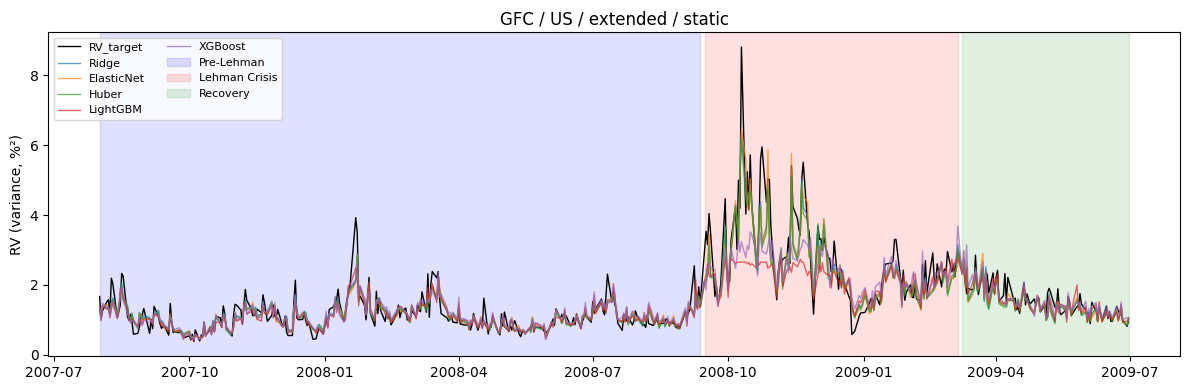

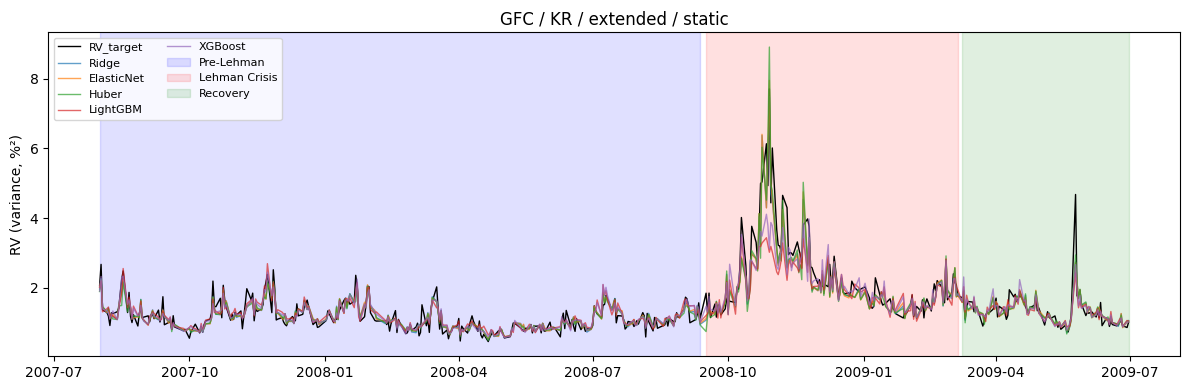

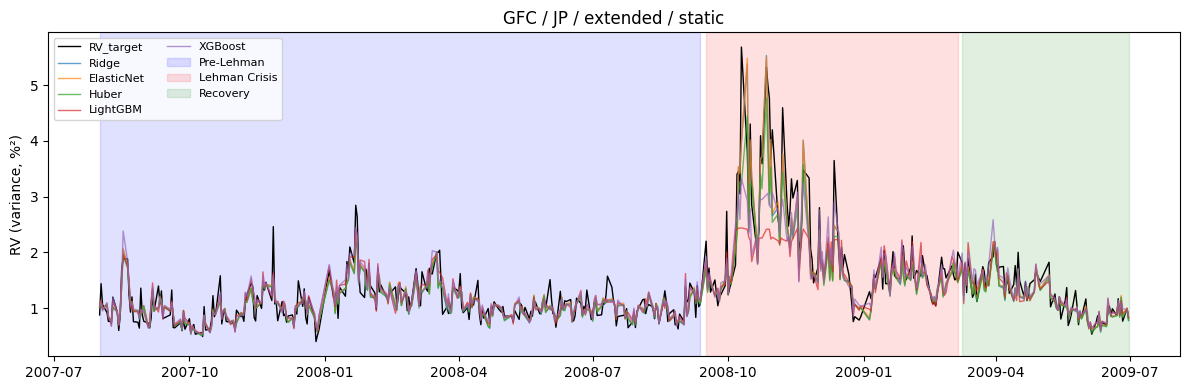

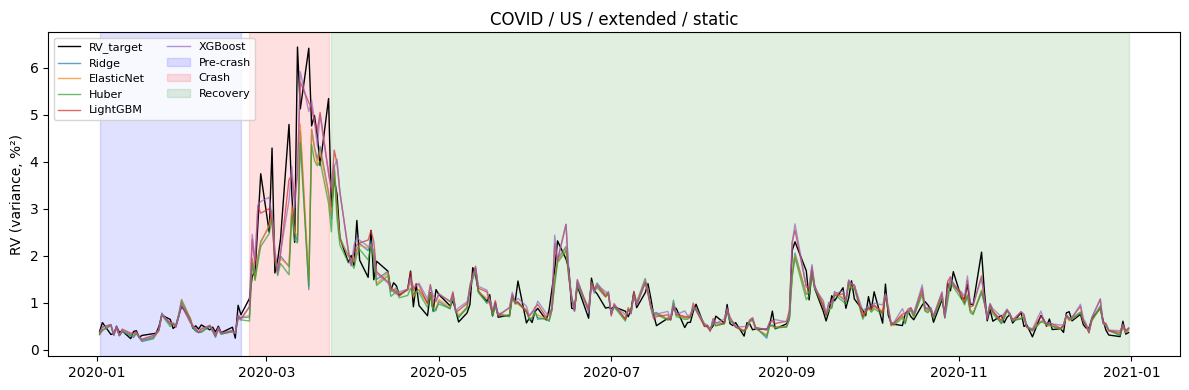

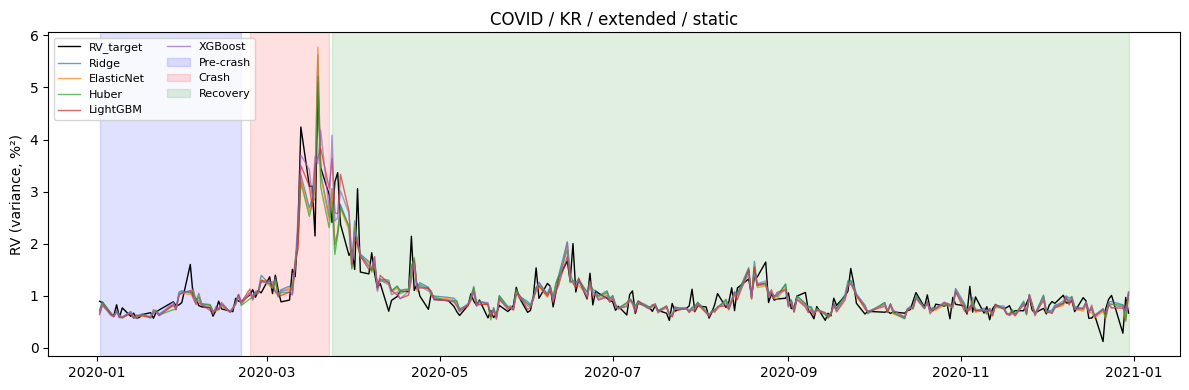

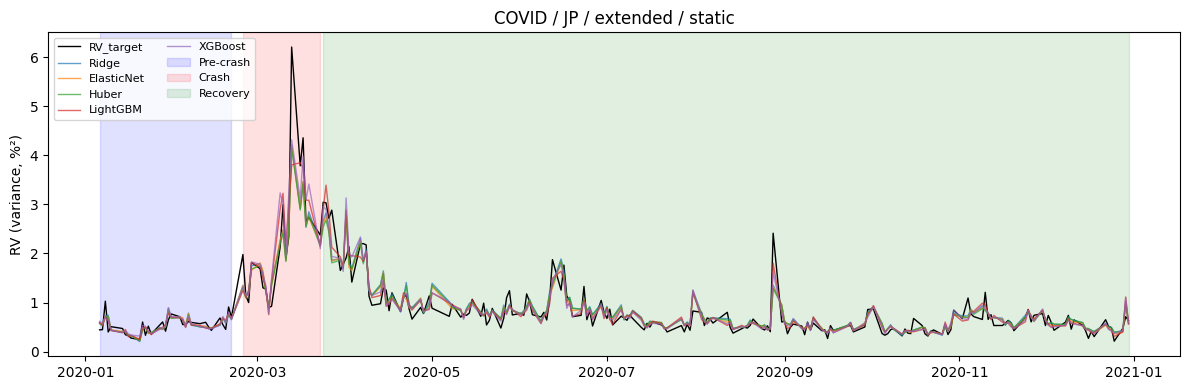

In [11]:
def plot_predictions(regime: str, country: str, tier: str = 'extended', protocol: str = 'static'):
    train, valid, test = load_split_3way(regime, country)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(test.index, test['RV_target'], color='black', lw=1, label='RV_target')
    for model_name in ALL_MODEL_NAMES:
        key = (model_name, regime, country, tier, protocol)
        if key in preds_cache:
            ax.plot(test.index, preds_cache[key], lw=1, alpha=0.7, label=model_name)
    for name, mask, color in iter_phases(test, regime):
        if name == 'Full Test' or color is None:
            continue
        idx = test.index[mask]
        if len(idx) > 0:
            ax.axvspan(idx.min(), idx.max(), color=color, alpha=0.12, label=name)
    ax.set_title(f'{regime.upper()} / {country} / {tier} / {protocol}')
    ax.set_ylabel('RV (variance, %²)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

for regime in ['gfc','covid']:
    for country in config.COUNTRIES:
        plot_predictions(regime, country, 'extended', 'static')

## 8. (선택) Tier 효과 분석 — Core → Momentum → Extended

In [12]:
tier_effect = (
    results_df[results_df['phase'] == 'Full Test']
    .groupby(['feature_set','model'])['QLIKE']
    .mean()
    .unstack('feature_set')
    .reindex(columns=TIERS)
    .round(4)
)
tier_effect['Δ Core→Momentum'] = (tier_effect['momentum'] - tier_effect['core']).round(4)
tier_effect['Δ Momentum→Extended'] = (tier_effect['extended'] - tier_effect['momentum']).round(4)
tier_effect

feature_set,core,momentum,extended,Δ Core→Momentum,Δ Momentum→Extended
model,,,,,
ElasticNet,0.0238,0.0239,0.0250,0.0001,0.0011
Huber,0.0392,0.0229,0.0353,-0.0163,0.0124
LightGBM,0.0200,0.0191,0.0195,-0.0009,0.0004
Ridge,0.0242,0.0239,0.0260,-0.0003,0.0021
XGBoost,0.0187,0.0186,0.0187,-0.0001,0.0001


## 9. (선택) Tuned hyperparameters 저장

In [13]:
tuned_rows = []
for (model, regime, country, tier), (params, qlike) in tuned_cache.items():
    row = {'model': model, 'regime': regime, 'country': country, 'feature_set': tier,
           'best_val_qlike': qlike}
    row.update({f'param_{k}': v for k, v in params.items()})
    tuned_rows.append(row)

tuned_df = pd.DataFrame(tuned_rows)
tuned_df.to_csv(config.RESULTS_DIR / 'ml_tuned_params.csv', index=False)
print(f'saved → ml_tuned_params.csv ({len(tuned_df)}행)')
tuned_df.head()

saved → ml_tuned_params.csv (180행)


,model,regime,country,feature_set,best_val_qlike,param_alpha,param_l1_ratio,param_epsilon,param_n_estimators,param_learning_rate,param_max_depth,param_num_leaves,param_min_child_samples,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda,param_min_child_weight,param_gamma
0,Ridge,normal,US,core,0.030850,90.128524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ElasticNet,normal,US,core,0.029733,0.007459,0.905643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Huber,normal,US,core,0.028992,0.131305,NaN,1.113074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LightGBM,normal,US,core,0.026166,NaN,NaN,NaN,1067.0,0.036173,5.0,202.0,6.0,0.812450,0.823519,0.000252,0.005816,NaN,NaN
4,XGBoost,normal,US,core,0.027388,NaN,NaN,NaN,391.0,0.028002,4.0,NaN,NaN,0.878103,0.895804,0.032402,0.015055,1.063482,0.006214
